In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import geopandas as gpd
from shapely.geometry import Point
import glob
import matplotlib.pyplot as plt
from scipy.signal import periodogram

In [4]:
# Function to read and process a single file
def read_celias_file(file_path):
    # Read the file
    df = pd.read_csv(file_path, sep='\s+', header=None, skiprows=27, 
                     names=["YY", "MON", "DY", "DOY:HH:MM:SS", "SPEED", "Np", "Vth", "N/S", 
                            "V_He", "GSE_X", "GSE_Y", "GSE_Z", "RANGE", "HGLAT", "HGLONG", "CRN(E)"],
                     dtype=str)
    
    # Remove rows where the DOY:HH:MM:SS column has non-numeric values
    df = df[pd.to_numeric(df["DOY:HH:MM:SS"].str.split(":").str[0], errors='coerce').notnull()]
    
    # Convert relevant columns to appropriate data types
    df["DOY"] = df["DOY:HH:MM:SS"].str.split(":").str[0].astype(int)
    df["HH"] = df["DOY:HH:MM:SS"].str.split(":").str[1].astype(int)
    df["MM"] = df["DOY:HH:MM:SS"].str.split(":").str[2].astype(int)
    df["SS"] = df["DOY:HH:MM:SS"].str.split(":").str[3].astype(int)
    
    # Create a datetime column
    df["datetime"] = pd.to_datetime(df["YY"].astype(str) + ' ' + df["MON"] + ' ' + df["DY"].astype(str) + ' ' + df["HH"].astype(str) + ':' + df["MM"].astype(str) + ':' + df["SS"].astype(str), format='%y %b %d %H:%M:%S')
    
    # Set the datetime column as the index
    df.set_index("datetime", inplace=True)
    
    # Drop the original date columns
    df.drop(columns=["YY", "MON", "DY", "DOY:HH:MM:SS", "DOY", "HH", "MM", "SS"], inplace=True)
    
    # Convert remaining columns to numeric, setting errors='coerce' to handle non-numeric values
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

# Path to the folder containing the data files
data_folder = "CELIAS_Proton_Monitor_5min (2)"

# Get a list of all data files
file_paths = glob.glob(f"{data_folder}/*_CELIAS_Proton_Monitor_5min.txt")

# Read and combine all data files
all_data = pd.concat([read_celias_file(file) for file in file_paths])


                          SPEED         Np        Vth       N/S        V_He  \
datetime                                                                      
1996-01-20 20:00:00  447.333333   9.963333  43.444444  1.644444  467.222222   
1996-01-20 21:00:00  437.583333   8.010833  41.083333  2.208333  455.666667   
1996-01-20 22:00:00  442.750000  10.515833  41.083333  1.583333  460.166667   
1996-01-20 23:00:00  431.909091  10.559091  38.000000  1.236364  446.181818   
1996-01-21 00:00:00  424.666667   7.991667  36.500000  0.808333  437.833333   

                          GSE_X       GSE_Y      GSE_Z  RANGE  HGLAT  \
datetime                                                               
1996-01-20 20:00:00  211.200000 -100.266667 -10.900000  145.9   -5.1   
1996-01-20 21:00:00  211.200000 -100.300000 -10.900000  145.9   -5.1   
1996-01-20 22:00:00  211.116667 -100.316667 -10.833333  145.9   -5.1   
1996-01-20 23:00:00  211.100000 -100.400000 -10.800000  145.9   -5.1   
1996-01-21 00:

In [5]:
# Resample the data to hourly frequency, taking the mean of each hour
hourly_data = all_data.resample('H').max()

# Save the processed data to a CSV file (optional)
hourly_data.to_csv("CELIAS_Proton_Monitor_Hourly.csv")

print(hourly_data.head())

                     SPEED     Np   Vth  N/S   V_He  GSE_X  GSE_Y  GSE_Z  \
datetime                                                                   
1996-01-20 20:00:00  450.0  10.78  44.0  2.1  470.0  211.2 -100.2  -10.9   
1996-01-20 21:00:00  444.0   9.38  44.0  4.3  465.0  211.2 -100.3  -10.9   
1996-01-20 22:00:00  448.0  11.59  44.0  2.6  468.0  211.2 -100.3  -10.8   
1996-01-20 23:00:00  439.0  11.71  40.0  1.8  455.0  211.1 -100.4  -10.8   
1996-01-21 00:00:00  442.0   8.92  40.0  1.0  458.0  211.1 -100.4  -10.8   

                     RANGE  HGLAT  HGLONG  CRN(E)  
datetime                                           
1996-01-20 20:00:00  145.9   -5.1   309.7  1905.0  
1996-01-20 21:00:00  145.9   -5.1   309.3  1905.0  
1996-01-20 22:00:00  145.9   -5.1   308.7  1905.0  
1996-01-20 23:00:00  145.9   -5.1   308.2  1905.0  
1996-01-21 00:00:00  145.9   -5.1   307.6  1905.0  


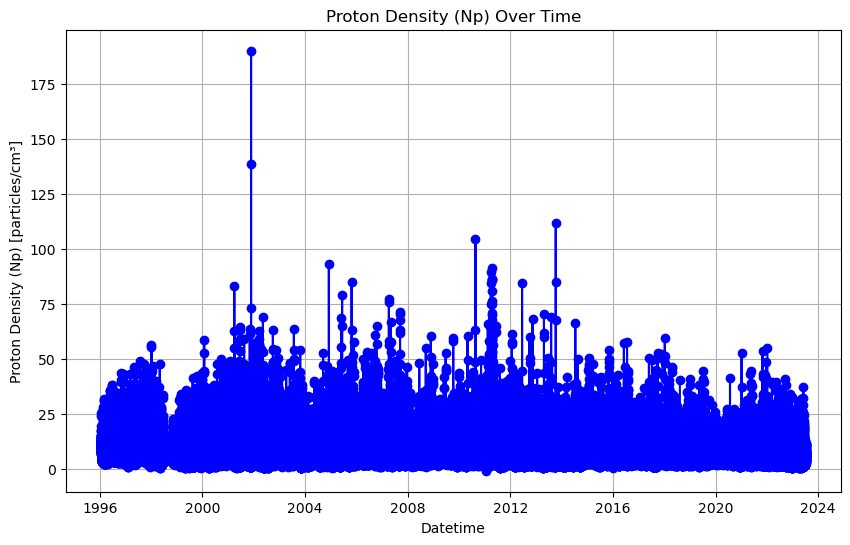

In [9]:
df = pd.read_csv("CELIAS_Proton_Monitor_Hourly.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df.set_index("datetime", inplace=True)

# Plotting the proton density (Np) over time
plt.figure(figsize=(10, 6))
plt.plot(df.index, df["Np"], marker='o', linestyle='-', color='b')
plt.title("Proton Density (Np) Over Time")
plt.xlabel("Datetime")
plt.ylabel("Proton Density (Np) [particles/cm³]")
plt.grid(True)
plt.show()

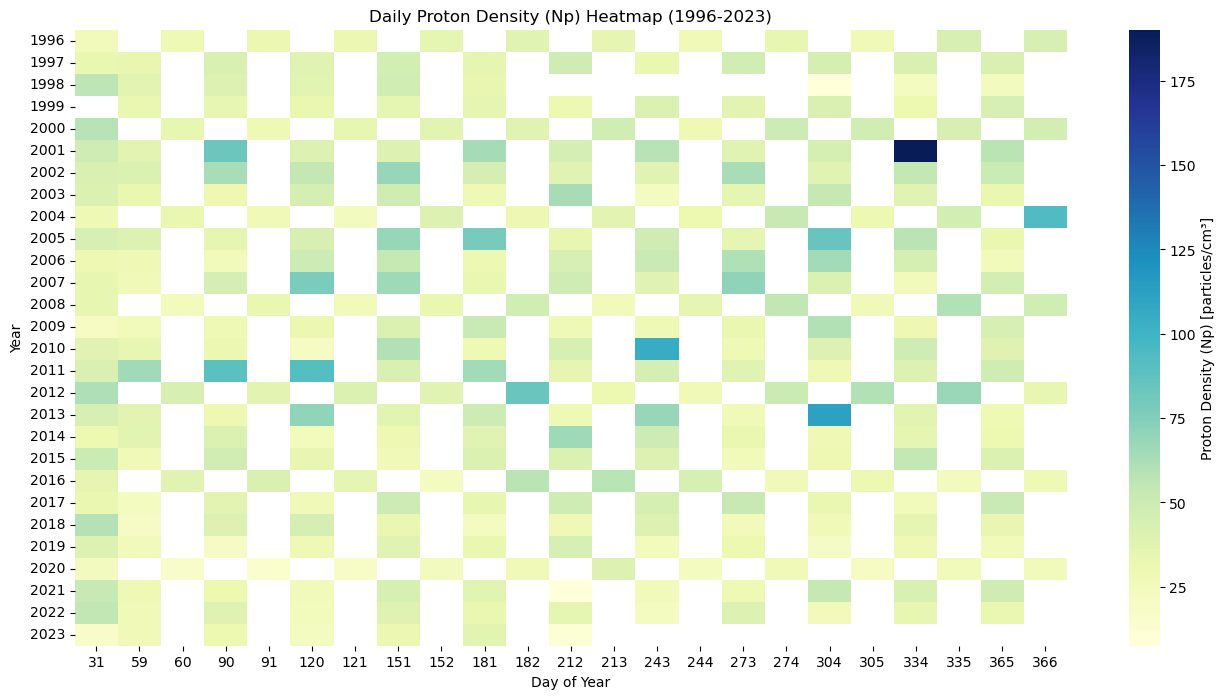

In [12]:
import seaborn as sns

# Resampling to daily averages for better granularity in the heatmap
daily_avg = df['Np'].resample('M').max()

# Preparing the data for a heatmap (Year vs Day of Year)
heatmap_data = daily_avg.groupby([daily_avg.index.year, daily_avg.index.dayofyear]).mean().unstack()

# Plotting the heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", cbar_kws={'label': 'Proton Density (Np) [particles/cm³]'})
plt.title('Daily Proton Density (Np) Heatmap (1996-2023)')
plt.xlabel('Day of Year')
plt.ylabel('Year')
plt.show()


C:\Users\STARLINECOMP\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



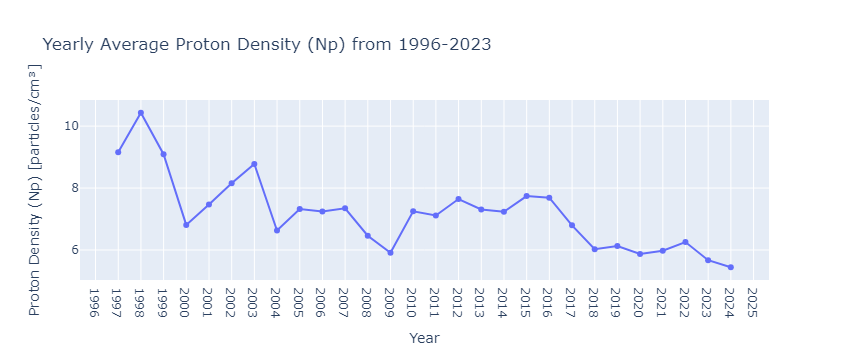

In [18]:
import plotly.express as px

# Subsample your data to yearly averages for the interactive plot
yearly_avg = df['Np'].resample('Y').mean().reset_index()

# Plotting
fig = px.line(yearly_avg, x='datetime', y='Np', title='Yearly Average Proton Density (Np) from 1996-2023',
              labels={'Np': 'Proton Density (Np) [particles/cm³]', 'datetime': 'Year'})
fig.update_traces(mode='lines+markers')
fig.update_xaxes(
    dtick="M12",  # This ensures ticks every 12 months (i.e., every year)
    tickformat="%Y",  # Format the ticks to show only the year
    tickmode='linear'  # Ensure linear spacing of ticks
)
fig.show()

C:\Users\STARLINECOMP\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



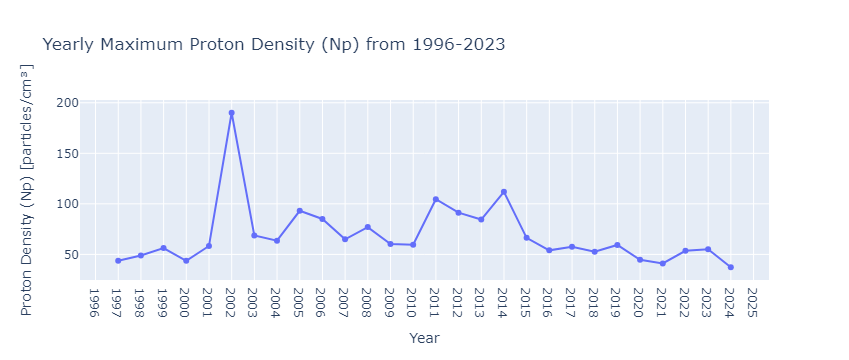

In [19]:
import plotly.express as px

# Subsample your data to yearly averages for the interactive plot
yearly_avg = df['Np'].resample('Y').max().reset_index()

# Plotting
fig = px.line(yearly_avg, x='datetime', y='Np', title='Yearly Maximum Proton Density (Np) from 1996-2023',
              labels={'Np': 'Proton Density (Np) [particles/cm³]', 'datetime': 'Year'})
fig.update_traces(mode='lines+markers')
fig.update_xaxes(
    dtick="M12",  # This ensures ticks every 12 months (i.e., every year)
    tickformat="%Y",  # Format the ticks to show only the year
    tickmode='linear'  # Ensure linear spacing of ticks
)
fig.show()

In [12]:
import pandas as pd
import numpy as np

# Load proton density data
proton_data = pd.read_csv("CELIAS_Proton_Monitor_Hourly.csv")  # Update path as needed
proton_data['datetime'] = pd.to_datetime(proton_data['datetime'])
proton_data.set_index('datetime', inplace=True)

# Load earthquake data
event_df = pd.read_csv("declustered_earthquake_dataset_usgs.csv")
event_df['time'] = pd.to_datetime(event_df['time'], format='mixed')

# Check if the datetime column is timezone-aware
if event_df['time'].dt.tz is None:
    # Localize to 'UTC' if not already timezone-aware
    event_df['time'] = event_df['time'].dt.tz_localize('UTC')
    
event_df['date'] = event_df['time'].dt.date
event_df = event_df[(event_df['mag'] > 7) & (event_df['depth'] < 60)]

# Ensure proton_data index is timezone-aware if needed
if proton_data.index.tz is None:
    proton_data.index = proton_data.index.tz_localize('UTC')

# Calculate total number of days
total_hours = proton_data.shape[0]
total_days = (proton_data.index[-1] - proton_data.index[0]).days + 1
print(f"Total days in dataset: {total_days}")

# Calculate total number of days and total number of events
total_days = (proton_data.index[-1] - proton_data.index[0]).days + 1
total_events = event_df.shape[0]

# Initialize variables to store results
best_V_T = None
best_failure_fraction = float('inf')

# Define function to calculate failure fraction
def calculate_failure_fraction(num_failures, total_predictions):
    if total_predictions == 0:
        return float('inf')  # Avoid division by zero
    return num_failures / total_predictions

# Loop through different V_T values in range 15-31
for V_T in np.arange(5, 32, 1):
    print(f"Testing V_T: {V_T}")

    # Add a column to check if Np is below the threshold
    proton_data['below_threshold'] = proton_data['Np'] > V_T

    # Get timestamps where density falls below the threshold
    threshold_fall_times = proton_data[proton_data['below_threshold']].index

    # Initialize counts for the current threshold
    num_failures = 0
    num_predictions = len(threshold_fall_times)
    
    # Count earthquakes occurring within 24 hours after each threshold fall time
    for fall_time in threshold_fall_times:
        end_time = fall_time + pd.Timedelta(hours=24)
        earthquakes_in_window = event_df[(event_df['time'] >= fall_time) & (event_df['time'] <= end_time)]
        num_failures += earthquakes_in_window.shape[0]

    # Calculate failure fraction
    failure_fraction = calculate_failure_fraction(num_failures, num_predictions)

    # Update best V_T based on failure fraction
    if failure_fraction < best_failure_fraction:
        best_failure_fraction = failure_fraction
        best_V_T = V_T

    print(f"V_T: {V_T}")
    print(f"Number of Predictions: {num_predictions}")
    print(f"Number of Failures: {num_failures}")
    print(f"Failure Fraction: {failure_fraction}")

# Print summary of results
print(f"Best V_T: {best_V_T}")
print(f"Failure Fraction for best V_T: {best_failure_fraction}")


Total days in dataset: 10030
Testing V_T: 5
V_T: 5
Number of Predictions: 138469
Number of Failures: 1713
Failure Fraction: 0.012371000007221833
Testing V_T: 6
V_T: 6
Number of Predictions: 110336
Number of Failures: 1340
Failure Fraction: 0.012144721577726218
Testing V_T: 7
V_T: 7
Number of Predictions: 86584
Number of Failures: 1079
Failure Fraction: 0.012461886722720134
Testing V_T: 8
V_T: 8
Number of Predictions: 67647
Number of Failures: 839
Failure Fraction: 0.012402619480538678
Testing V_T: 9
V_T: 9
Number of Predictions: 53045
Number of Failures: 690
Failure Fraction: 0.013007823546045811
Testing V_T: 10
V_T: 10
Number of Predictions: 41927
Number of Failures: 544
Failure Fraction: 0.012974932620984092
Testing V_T: 11
V_T: 11
Number of Predictions: 33158
Number of Failures: 430
Failure Fraction: 0.012968212799324447
Testing V_T: 12
V_T: 12
Number of Predictions: 26533
Number of Failures: 346
Failure Fraction: 0.013040364828703879
Testing V_T: 13
V_T: 13
Number of Predictions: 2

In [13]:
event_df

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,date
20,1996-02-17 05:59:30.550000+00:00,-0.8910,136.9520,33.000,8.09,mww,NaN,NaN,NaN,NaN,...,"101 km ENE of Biak, Indonesia",earthquake,NaN,NaN,NaN,NaN,reviewed,us,duputel,1996-02-17
25,1996-02-21 12:51:01.300000+00:00,-9.5930,-79.5870,10.000,7.50,mw,NaN,NaN,NaN,1.20,...,"123 km WSW of Puerto Santa, Peru",earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv,1996-02-21
27,1996-02-25 03:08:15.870000+00:00,15.9780,-98.0700,21.100,7.10,mw,NaN,NaN,NaN,1.20,...,"24 km SSW of Santa María Chico Ometepec, Mexico",earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv,1996-02-25
176,1996-11-12 16:59:44.030000+00:00,-14.9930,-75.6750,33.000,7.70,mwc,NaN,NaN,NaN,1.11,...,"60 km SW of Changuillo, Peru",earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv,1996-11-12
201,1997-01-11 20:28:26.020000+00:00,18.2190,-102.7560,33.000,7.20,mwb,NaN,NaN,NaN,1.09,...,"46 km WNW of El Habillal, Mexico",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us,1997-01-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5250,2021-12-14 03:20:23.809000+00:00,-7.6033,122.2274,14.270,7.30,mww,NaN,32.0,1.025,0.61,...,Flores Sea,earthquake,5.10,2.600,0.055,32.0,reviewed,us,us,2021-12-14
5394,2022-09-19 18:05:08.217000+00:00,18.4552,-102.9561,26.943,7.60,mww,271.0,69.0,1.153,0.76,...,"35 km SSW of Aguililla, Mexico",earthquake,5.57,1.465,0.025,159.0,reviewed,us,us,2022-09-19
5463,2023-02-06 01:17:34.342000+00:00,37.2256,37.0143,10.000,7.80,mww,266.0,17.0,0.165,0.66,...,"Pazarcik earthquake, Kahramanmaras earthquake ...",earthquake,5.23,1.784,0.050,38.0,reviewed,us,us,2023-02-06
5524,2023-05-19 02:57:03.172000+00:00,-23.2063,170.7423,18.053,7.70,mww,278.0,15.0,3.096,0.89,...,southeast of the Loyalty Islands,earthquake,7.07,2.580,0.035,79.0,reviewed,us,us,2023-05-19


In [11]:
import pandas as pd
import numpy as np

# Load proton density data
proton_data = pd.read_csv("CELIAS_Proton_Monitor_Hourly.csv")  # Update path as needed
proton_data['datetime'] = pd.to_datetime(proton_data['datetime'])
proton_data.set_index('datetime', inplace=True)

# Load earthquake data
event_df = pd.read_csv("declustered_earthquake_dataset_usgs.csv")
event_df['time'] = pd.to_datetime(event_df['time'], format='mixed')

# Check if the datetime column is timezone-aware
if event_df['time'].dt.tz is None:
    # Localize to 'UTC' if not already timezone-aware
    event_df['time'] = event_df['time'].dt.tz_localize('UTC')
    
event_df['date'] = event_df['time'].dt.date
event_df = event_df[(event_df['mag'] > 6) & (event_df['depth'] < 60)]

# Ensure proton_data index is timezone-aware if needed
if proton_data.index.tz is None:
    proton_data.index = proton_data.index.tz_localize('UTC')

# Calculate total number of days
total_hours = proton_data.shape[0]
total_days = (proton_data.index[-1] - proton_data.index[0]).days + 1
print(f"Total days in dataset: {total_days}")

# Calculate total number of days and total number of events
total_days = (proton_data.index[-1] - proton_data.index[0]).days + 1
total_events = event_df.shape[0]

# Initialize variables to store results
best_V_T = None
best_failure_fraction = float('inf')

# Define function to calculate failure fraction
def calculate_failure_fraction(num_failures, total_predictions):
    if total_predictions == 0:
        return float('inf')  # Avoid division by zero
    return num_failures / total_predictions

# Loop through different V_T values in range 15-31
for V_T in np.arange(5, 32, 1):
    print(f"Testing V_T: {V_T}")

    # Add a column to check if Np is below the threshold
    proton_data['below_threshold'] = proton_data['Np'] > V_T

    # Get timestamps where density falls below the threshold
    threshold_fall_times = proton_data[proton_data['below_threshold']].index

    # Initialize counts for the current threshold
    num_failures = 0
    num_predictions = len(threshold_fall_times)

    # Count earthquakes occurring within 24 hours after each threshold fall time
    for fall_time in threshold_fall_times:
        end_time = fall_time + pd.Timedelta(hours=24)
        earthquakes_in_window = event_df[(event_df['time'] >= fall_time) & (event_df['time'] <= end_time)]
        num_failures += earthquakes_in_window.shape[0]

    # Calculate failure fraction
    failure_fraction = calculate_failure_fraction(num_failures, num_predictions)

    # Update best V_T based on failure fraction
    if failure_fraction < best_failure_fraction:
        best_failure_fraction = failure_fraction
        best_V_T = V_T

    print(f"V_T: {V_T}")
    print(f"Number of Predictions: {num_predictions}")
    print(f"Number of Failures: {num_failures}")
    print(f"Failure Fraction: {failure_fraction}")

# Print summary of results
print(f"Best V_T: {best_V_T}")
print(f"Failure Fraction for best V_T: {best_failure_fraction}")


Total days in dataset: 10030
Testing V_T: 5
V_T: 5
Number of Predictions: 138469
Number of Failures: 17159
Failure Fraction: 0.12391943323054258
Testing V_T: 6
V_T: 6
Number of Predictions: 110336
Number of Failures: 13752
Failure Fraction: 0.12463747099767981
Testing V_T: 7
V_T: 7
Number of Predictions: 86584
Number of Failures: 10976
Failure Fraction: 0.1267670701284302
Testing V_T: 8
V_T: 8
Number of Predictions: 67647
Number of Failures: 8731
Failure Fraction: 0.12906706875397284
Testing V_T: 9
V_T: 9
Number of Predictions: 53045
Number of Failures: 6891
Failure Fraction: 0.12990856819681404
Testing V_T: 10
V_T: 10
Number of Predictions: 41927
Number of Failures: 5492
Failure Fraction: 0.13098957712214088
Testing V_T: 11
V_T: 11
Number of Predictions: 33158
Number of Failures: 4338
Failure Fraction: 0.13082815610109175
Testing V_T: 12
V_T: 12
Number of Predictions: 26533
Number of Failures: 3452
Failure Fraction: 0.13010213696151962
Testing V_T: 13
V_T: 13
Number of Predictions: 21

In [15]:
import pandas as pd
import numpy as np

# Load proton density data
proton_data = pd.read_csv("CELIAS_Proton_Monitor_Hourly.csv")  # Update path as needed
proton_data['datetime'] = pd.to_datetime(proton_data['datetime'])
proton_data.set_index('datetime', inplace=True)

# Load earthquake data
event_df = pd.read_csv("declustered_earthquake_dataset_usgs.csv")
event_df['time'] = pd.to_datetime(event_df['time'], format='mixed')

# Check if the datetime column is timezone-aware
if event_df['time'].dt.tz is None:
    # Localize to 'UTC' if not already timezone-aware
    event_df['time'] = event_df['time'].dt.tz_localize('UTC')
    
event_df['date'] = event_df['time'].dt.date
event_df = event_df[(event_df['mag'] > 6) & (event_df['depth'] < 60)]

training_start_date = pd.Timestamp('1996-01-01')
training_end_date = pd.Timestamp('2005-12-31')

# Ensure proton_data index is timezone-aware if needed
if proton_data.index.tz is None:
    proton_data.index = proton_data.index.tz_localize('UTC')

# Calculate total number of days
total_hours = proton_data.shape[0]
total_days = (proton_data.index[-1] - proton_data.index[0]).days + 1
print(f"Total days in dataset: {total_days}")

# Calculate total number of days and total number of events
total_days = (proton_data.index[-1] - proton_data.index[0]).days + 1
total_events = event_df.shape[0]

# Initialize variables to store results
best_V_T = None
best_failure_fraction = float('inf')

# Define function to calculate failure fraction
def calculate_failure_fraction(num_failures, total_predictions):
    if total_predictions == 0:
        return float('inf')  # Avoid division by zero
    return num_failures / total_predictions

# Loop through different V_T values in range 15-31
for V_T in np.arange(5, 6, 1):
    print(f"Testing V_T: {V_T}")

    # Add a column to check if Np is below the threshold
    proton_data['below_threshold'] = proton_data['Np'] < V_T

    # Get timestamps where density falls below the threshold
    threshold_fall_times = proton_data[proton_data['below_threshold']].index

    # Initialize counts for the current threshold
    num_failures = 0
    num_predictions = 0

    # Track the first fall time each day
    seen_dates = set()

    # Iterate over each fall time
    for fall_time in threshold_fall_times:
        fall_date = fall_time.date()
        if fall_date not in seen_dates:
            # First fall time for this day
            seen_dates.add(fall_date)
            num_predictions += 1

            # Count earthquakes occurring within 24 hours after this fall time
            end_time = fall_time + pd.Timedelta(hours=24)
            earthquakes_in_window = event_df[(event_df['time'] >= fall_time) & (event_df['time'] <= end_time)]
            num_failures += earthquakes_in_window.shape[0]
    # print(seen_dates)
    # Calculate failure fraction
    failure_fraction = calculate_failure_fraction(num_failures, num_predictions)

    # Update best V_T based on failure fraction
    if failure_fraction < best_failure_fraction:
        best_failure_fraction = failure_fraction
        best_V_T = V_T

    print(f"V_T: {V_T}")
    print(f"Number of Predictions: {num_predictions}")
    print(f"Number of Failures: {num_failures}")
    print(f"Failure Fraction: {failure_fraction}")

# Print summary of results
print(f"Best V_T: {best_V_T}")
print(f"Failure Fraction for best V_T: {best_failure_fraction}")


Total days in dataset: 10030
Testing V_T: 5
V_T: 5
Number of Predictions: 7044
Number of Failures: 98
Failure Fraction: 0.013912549687677456
Best V_T: 5
Failure Fraction for best V_T: 0.013912549687677456


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load proton density data
proton_data = pd.read_csv("CELIAS_Proton_Monitor_Hourly.csv")  # Update path as needed
proton_data['datetime'] = pd.to_datetime(proton_data['datetime'])
proton_data.set_index('datetime', inplace=True)

# Load earthquake data
event_df = pd.read_csv("declustered_earthquake_dataset_usgs.csv")
event_df['time'] = pd.to_datetime(event_df['time'], format='mixed')

# Check if the datetime column is timezone-aware
if event_df['time'].dt.tz is None:
    # Localize to 'UTC' if not already timezone-aware
    event_df['time'] = event_df['time'].dt.tz_localize('UTC')

# Add year columns to both datasets
proton_data['year'] = proton_data.index.year
event_df['year'] = event_df['time'].dt.year

# Get unique years from the datasets
years = sorted(proton_data['year'].unique())

# Create output directory for plots
output_dir = "daily_plots"
os.makedirs(output_dir, exist_ok=True)

threshold_value = 15

for year in years:
    # Filter data for the current year
    proton_yearly_data = proton_data[proton_data['year'] == year]
    earthquakes_yearly_data = event_df[event_df['year'] == year]

    # Aggregate proton density data by day for the current year
    proton_density_daily = proton_yearly_data.resample('D').max()['Np']

    # Aggregate earthquake data by day for the current year
    earthquakes_daily = earthquakes_yearly_data.groupby(earthquakes_yearly_data['time'].dt.date).size()

    # Create the plot
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Plot proton density
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Proton Density', color='tab:blue')
    ax1.plot(proton_density_daily.index, proton_density_daily.values, 'o-', color='tab:blue', label='Average Proton Density')
    ax1.axhline(y=threshold_value, color='r', linestyle='--', label=f'Threshold ({threshold_value})')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_title(f'Proton Density and Earthquakes in {year}')

    # Create a second y-axis for the number of earthquakes
    ax2 = ax1.twinx()
    ax2.set_ylabel('Number of Earthquakes', color='tab:orange')
    ax2.bar(earthquakes_daily.index, earthquakes_daily.values, alpha=0.6, color='tab:orange', label='Number of Earthquakes')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    # Add legends
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Save the plot
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'proton_density_earthquakes_{year}.png'))
    plt.close()

print("Daily plots for each year with threshold 15 have been saved.")


Daily plots for each year with threshold 15 have been saved.
